In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import joblib
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ── Configurations ─────────

In [462]:
TICKER = "AAPL"
 
PERIOD    = "16y"
TRAIN_PCT = 0.8     # 80% train, 20% test


W = 90      # lookback window (hyperparameter, tune later)
FEATURES = [       # the 10 features — input to the LSTM
    "return",
    "lag1",
    "lag5",
    "lag10",
    "ma10",
    "ma50",
    'price_vs_ma50',
    'high_low_range',
    "volatility5",
    "volatility10",
    "volatility20",
    "volatility60",
    'vol_ratio',
    "rsi",
    "macd",
    'volume_change',
    "volume_ratio"
]
TARGET = "volatility20"   # what we predict

In [463]:
len(FEATURES)

17

# ────── feature enginering ───────

In [464]:
from functions import load_ticker

data = load_ticker(TICKER, PERIOD)

[*********************100%***********************]  1 of 1 completed


# ── Train / test split ─────────

In [465]:
from functions import split_data

train_data, test_data = split_data(data, TRAIN_PCT)

train=3172 rows, test=793 rows, split date=2023-02-07


# ── Visualization ─────────

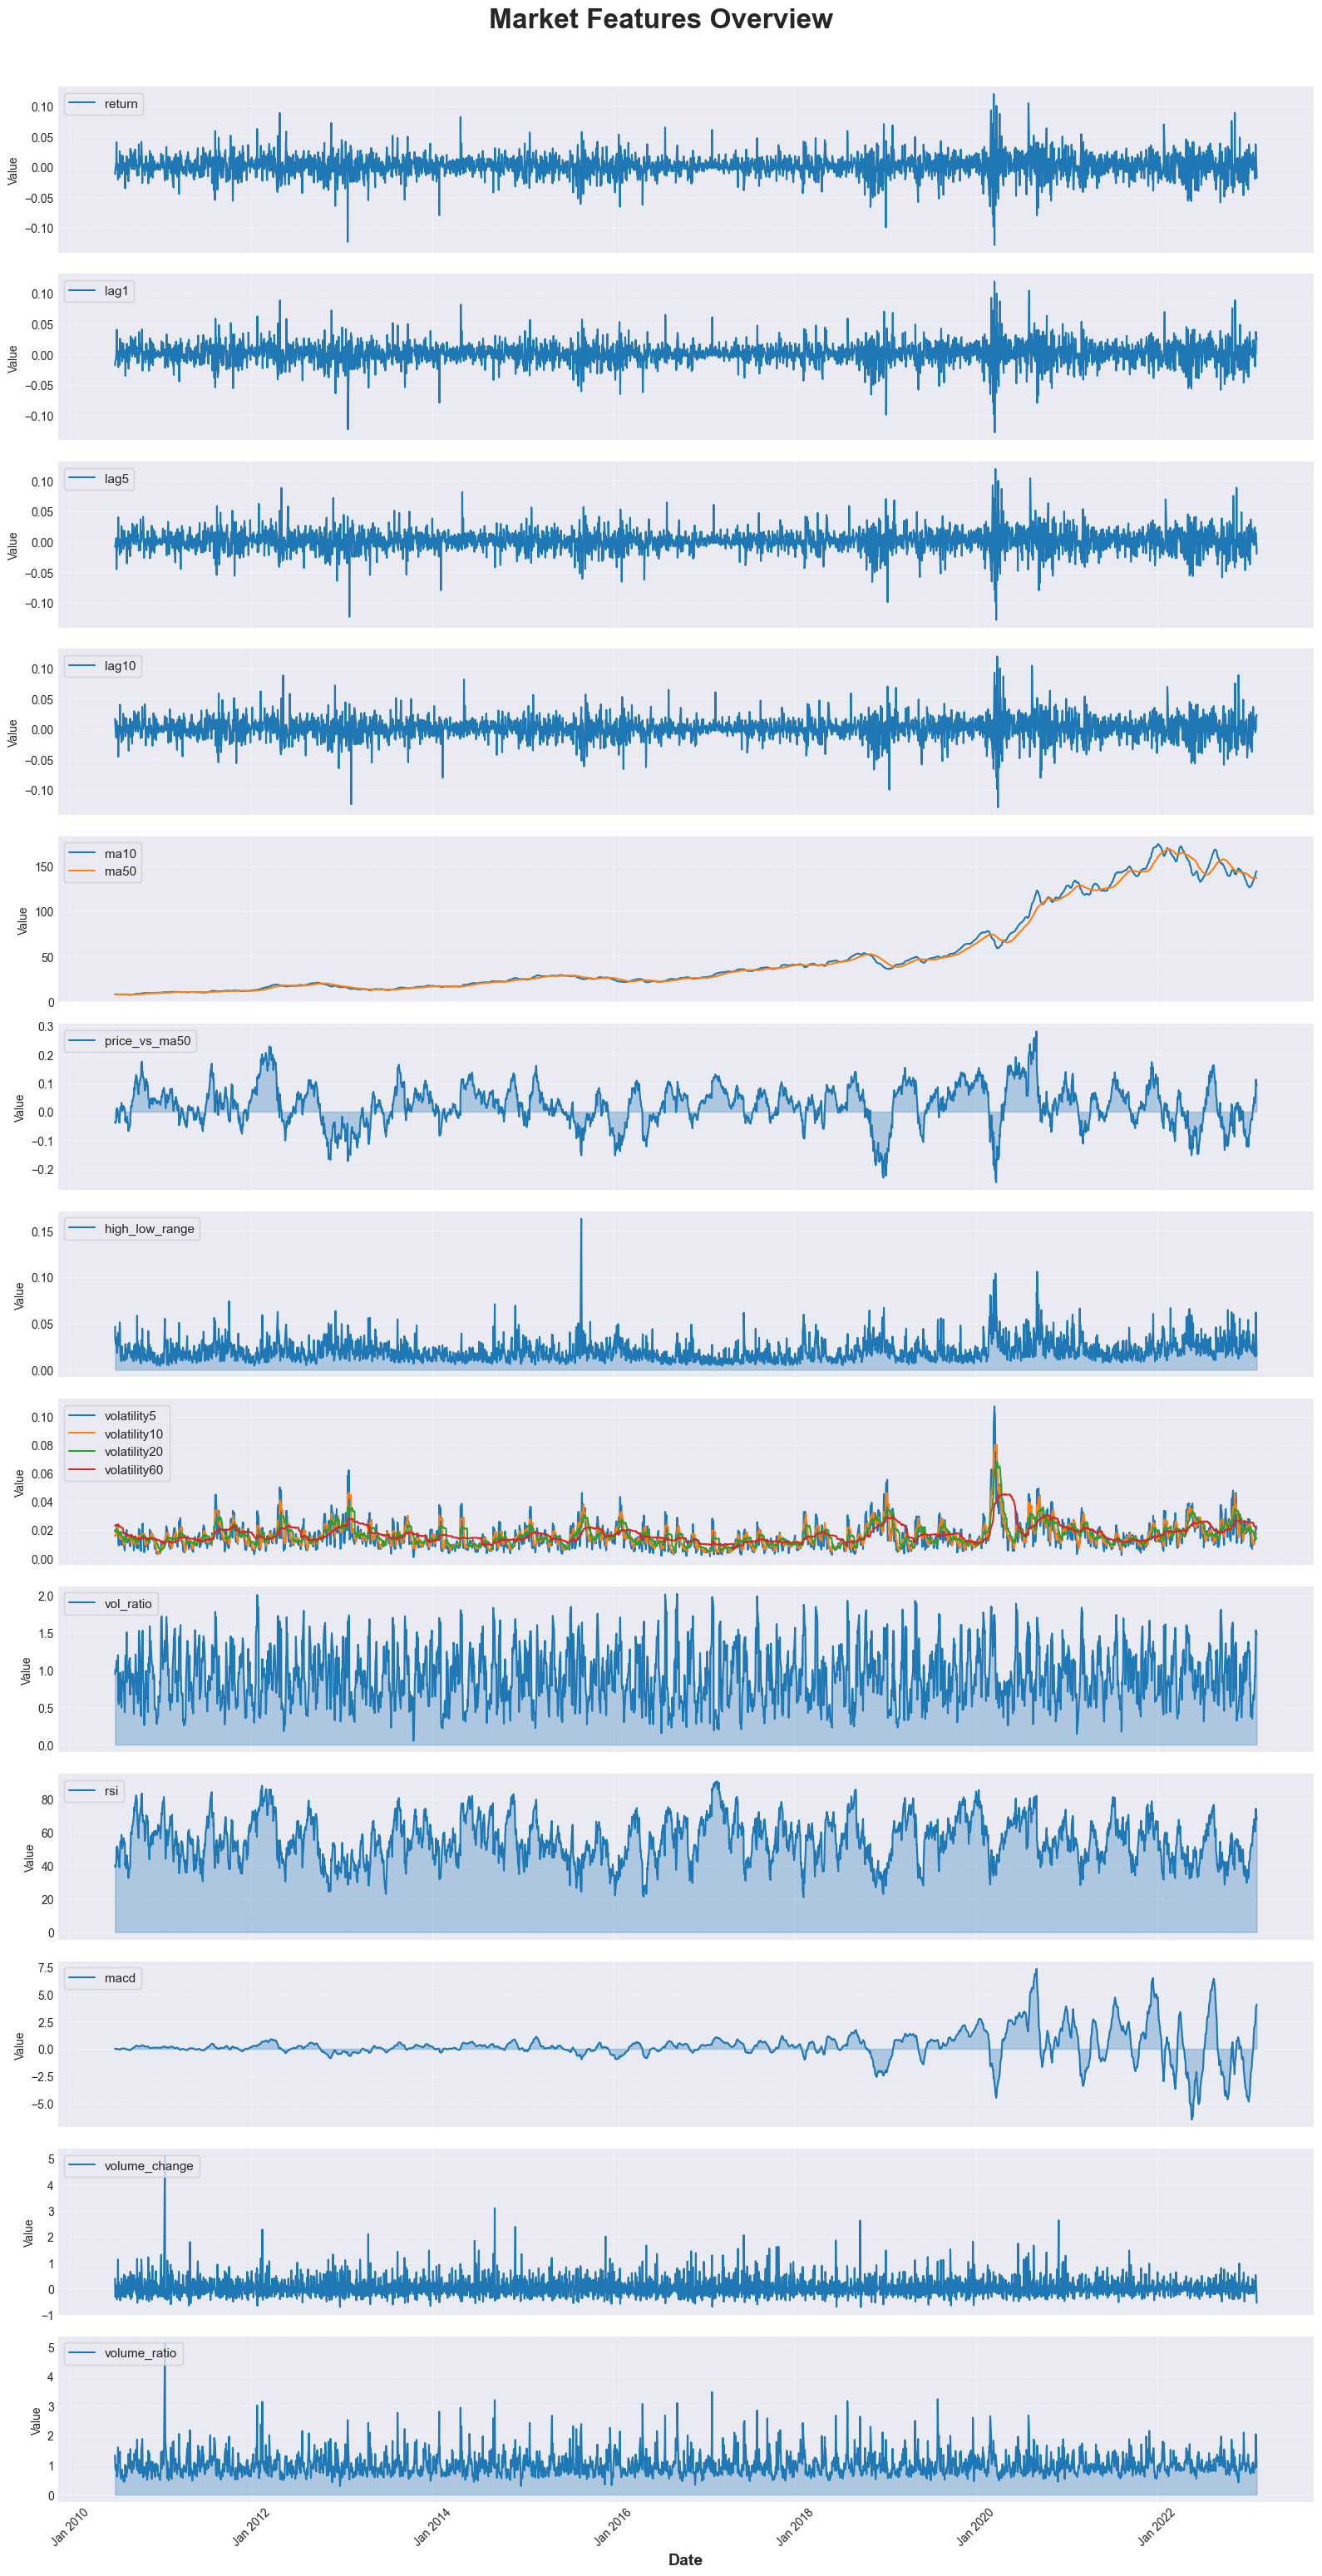

In [466]:
train_data.index = pd.to_datetime(train_data.index)

plot_groups = [
    ["return"],
    ["lag1"],
    ["lag5"],
    ["lag10"],
    ["ma10", "ma50"], 
    ['price_vs_ma50'],
    ['high_low_range'],
    ["volatility5", "volatility10", "volatility20", "volatility60"], 
    ['vol_ratio'],
    ["rsi"],
    ["macd"],
    ['volume_change'],
    ["volume_ratio"]
]

# Visualization Setup
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(nrows=13, ncols=1, figsize=(16, 34), sharex=True)
fig.suptitle('Market Features Overview', fontsize=24, fontweight='bold', y=0.91)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

# Plotting Loop
for i, (ax, group) in enumerate(zip(axes, plot_groups)):
    for j, feature in enumerate(group):
        color = colors[j % len(colors)]
        
        if len(group) == 1:
            ax.fill_between(train_data.index, train_data[feature], alpha=0.3, color=color)
            
        ax.plot(train_data.index, train_data[feature], label=feature, color=color, linewidth=1.5)
    
    ax.legend(loc='upper left', frameon=True, fontsize=11)
    ax.set_ylabel('Value', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# --- FIX 2: Force Matplotlib to limit the number of X-axis ticks ---
axes[-1].set_xlabel('Date', fontsize=14, fontweight='bold')

# Automatically pick the best dates to show, keeping it to around 10 max
locator = mdates.AutoDateLocator(minticks=5, maxticks=10)
axes[-1].xaxis.set_major_locator(locator)

# Format them nicely (e.g., 'Jan 2023')
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.xticks(rotation=45)
plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

# ── Sliding window ─────────
it's making the instances

In [467]:
from functions import make_windows

# ── fitting the Scaler ─────────

In [468]:
from functions import fit_scaler

# ── Scaling ─────────

In [469]:
from functions import apply_scaler

In [470]:
X_train, y_train = make_windows(train_data, W, features=FEATURES, target=TARGET)

number of instances : 3082


In [471]:
y_train

array([0.01383029, 0.01397374, 0.01398225, ..., 0.01435438, 0.01396916,
       0.0139554 ], shape=(3082,))

In [472]:
X_train.shape

(3082, 90, 17)

In [473]:
y_train.shape

(3082,)

In [474]:
X_train[0]

array([[-1.21261813e-02, -1.81130553e-02, -7.27071250e-03, ...,
         2.75978339e-02,  3.83316294e-01,  1.32336451e+00],
       [-6.19679002e-03, -1.21261813e-02, -8.54977039e-03, ...,
        -6.70643627e-03, -3.21687835e-01,  9.01412990e-01],
       [ 6.84302236e-03, -6.19679002e-03,  5.99894049e-03, ...,
        -2.94675546e-02, -1.13292521e-01,  8.13650165e-01],
       ...,
       [ 1.11199798e-02,  1.70292049e-02, -7.13852868e-04, ...,
         1.93295817e-01,  1.71498629e-01,  8.80679055e-01],
       [ 1.74875027e-02,  1.11199798e-02, -8.41364099e-03, ...,
         2.06773768e-01,  2.63873359e-01,  1.09094557e+00],
       [-3.58215547e-03,  1.74875027e-02, -1.39566680e-02, ...,
         2.12251956e-01, -4.37727709e-01,  6.29284080e-01]],
      shape=(90, 17))

In [475]:
y_train[0]

np.float64(0.01383029374605065)

In [476]:
scaler = fit_scaler(X_train)

In [ ]:
# joblib.dump(scaler, f"../models/scaler1.pkl")

['../models/scaler1.pkl']

In [478]:
X_train_scaled = apply_scaler(X_train, scaler)

In [479]:
X_train_scaled.shape

(3082, 90, 17)

In [480]:
X_train_scaled[0]

array([[-0.72166162, -1.05401468, -0.45256514, ..., -0.20033291,
         1.04274732,  1.07786536],
       [-0.39285749, -0.72190909, -0.52351741, ..., -0.24412448,
        -0.78310198, -0.03348982],
       [ 0.33024274, -0.39299221,  0.28353283, ..., -0.27318048,
        -0.24339104, -0.26464355],
       ...,
       [ 0.56741401,  0.89540681, -0.08884115, ...,  0.01119104,
         0.49417304, -0.0880998 ],
       [ 0.92051397,  0.56760859, -0.515966  , ...,  0.0283965 ,
         0.733409  ,  0.46570974],
       [-0.24786745,  0.92082964, -0.82345038, ...,  0.03538975,
        -1.08362691, -0.75023537]], shape=(90, 17))

In [481]:
y_train.mean()

np.float64(0.01656635997480333)

In [482]:
X_train_scaled.mean()

np.float64(0.16639203309815453)

# ──────────  Trainig the Model  ──────────
the best part ^_^

In [483]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE   # lenovo legion with RTX 4060 ^_^

device(type='cuda')

# ── Hyperparameters ───────────

In [484]:
# these are starting values, we will tune them later
HIDDEN_SIZE = 128       # number of LSTM units per layer
NUM_LAYERS = 1        # number of stacked LSTM layers
DROPOUT = 0.29255451180333386      # dropout between LSTM layers (regularization)
LEARNING_RATE = 0.0011482784997348093
BATCH_SIZE = 64
EPOCHS = 100
PATIENCE = 17

# ── Dataset ──────────

In [485]:
class StockDataset(Dataset):
    """
    Simple PyTorch Dataset wrapper around our numpy arrays.
    Converts them to float32 tensors and moves to device.
    """
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
 
    def __len__(self):
        return len(self.X)
 
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# ── Model ^_^ ─────────

In [486]:
class StockLSTM(nn.Module):
    """
    LSTM model for stock return prediction.
 
    Architecture:
        Input  → LSTM layers → Dropout → Linear → Output
 
    Input shape:  (batch_size, W, n_features)
    Output shape: (batch_size, 1)
    """
    def __init__(self, n_features: int, hidden_size: int, num_layers: int, dropout: float):
        super(StockLSTM, self).__init__()
 
        self.lstm = nn.LSTM(
            input_size   = n_features,
            hidden_size  = hidden_size,
            num_layers   = num_layers,
            dropout      = dropout if num_layers > 1 else 0,  # dropout only between layers
            batch_first  = True    # input shape: (batch, seq, features)
        )
 
        self.dropout = nn.Dropout(dropout)
        self.linear  = nn.Linear(hidden_size, 1)
 
    def forward(self, x):
        # x shape: (batch_size, W, n_features)
 
        lstm_out, _ = self.lstm(x)
        # lstm_out shape: (batch_size, W, hidden_size)
 
        # take only the last timestep's output
        # because we want to predict the next day after the sequence ends
        last_out = lstm_out[:, -1, :]
        # last_out shape: (batch_size, hidden_size)
 
        out = self.dropout(last_out)
        out = self.linear(out)
        out = torch.relu(out)
        # out shape: (batch_size, 1)
 
        return out.squeeze(1)   # shape: (batch_size,)

In [487]:
def quantile_loss(preds, target, quantile=0.63):
    """
    Calculate the pinball/quantile loss.
    quantile: float between 0 and 1 (e.g., 0.9 for the 90th percentile).
    """
    errors = target - preds
    loss = torch.max((quantile - 1) * errors, quantile * errors)
    return loss.mean()

# ── Training loop ──────────

In [488]:
def train_model(model, train_loader, val_loader, epochs, lr, device):
    """
    Trains the model and returns train/val loss history.
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    # criterion = nn.MSELoss()
 
    # reduce learning rate if validation loss plateaus
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5
    )
 
    train_losses = []
    val_losses   = []
    best_val_loss = float("inf")
    best_weights  = None
    
    patience_counter = 0

    for epoch in range(1, epochs + 1):
 
        # ── training phase
        model.train()
        batch_losses = []
 
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
 
            optimizer.zero_grad()
            predictions = model(X_batch)
            loss = quantile_loss(predictions, y_batch)
            loss.backward()
 
            # gradient clipping — prevents exploding gradients in LSTMs
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
 
            optimizer.step()
            batch_losses.append(loss.item())
 
        train_loss = np.mean(batch_losses)
        train_losses.append(train_loss)
 
        # ── validation phase
        model.eval()
        val_batch_losses = []
 
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)
                predictions = model(X_batch)
                loss = quantile_loss(predictions, y_batch)
                val_batch_losses.append(loss.item())
 
        val_loss = np.mean(val_batch_losses)
        val_losses.append(val_loss)
 
        # update learning rate scheduler
        prev_lr = optimizer.param_groups[0]["lr"]
        scheduler.step(val_loss)
        new_lr = optimizer.param_groups[0]["lr"]
        if new_lr < prev_lr:
            print(f"  → learning rate reduced to {new_lr:.2e}")
 
        # save best weights
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights  = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"\nEarly stopping at epoch {epoch}")
                break
 
        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch {epoch:3d}/{epochs} — "
                  f"train loss: {train_loss:.6f} — "
                  f"val loss: {val_loss:.6f}")
 
    # restore best weights
    model.load_state_dict(best_weights)
    print(f"\nBest val loss: {best_val_loss:.6f}")
 
    return train_losses, val_losses

# ── Evaluation ──────────

In [489]:
from sklearn.metrics import root_mean_squared_error

def evaluate_model(model, loader, device):
    """
    Returns predictions and true values for a dataset.
    Also computes RMSE and directional accuracy.
    """
    model.eval()
    all_preds = []
    all_true  = []
 
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            preds   = model(X_batch).cpu().numpy()
            all_preds.extend(preds)
            all_true.extend(y_batch.numpy())
 
    preds = np.array(all_preds)
    true  = np.array(all_true)
 
    rmse = root_mean_squared_error(true, preds)
 
    return preds, true, rmse

In [490]:
X_test, y_test = make_windows(test_data, W, features=FEATURES, target=TARGET)

number of instances : 703


In [491]:
X_test_scaled = apply_scaler(X_test, scaler)

In [492]:
tr_data, val_data = split_data(train_data, 0.9)

train=2854 rows, test=318 rows, split date=2021-11-01


In [493]:
X_tr, y_tr = make_windows(tr_data, W, features=FEATURES, target=TARGET)
X_tr_scaled = apply_scaler(X_tr, scaler)

number of instances : 2764


In [494]:
X_val, y_val = make_windows(val_data, W, features=FEATURES, target=TARGET)
X_val_scaled = apply_scaler(X_val, scaler)

number of instances : 228


In [495]:
# ── create dataloaders
train_loader = DataLoader(StockDataset(X_tr_scaled, y_tr), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(StockDataset(X_val_scaled, y_val), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(StockDataset(X_test_scaled, y_test), batch_size=BATCH_SIZE, shuffle=False)

In [496]:
# ── build model
n_features = len(FEATURES)
model = StockLSTM(
    n_features = n_features,
    hidden_size = HIDDEN_SIZE,
    num_layers = NUM_LAYERS,
    dropout = DROPOUT
).to(DEVICE)

In [497]:
model

StockLSTM(
  (lstm): LSTM(17, 128, batch_first=True)
  (dropout): Dropout(p=0.29255451180333386, inplace=False)
  (linear): Linear(in_features=128, out_features=1, bias=True)
)

In [498]:
total_params = sum(p.numel() for p in model.parameters())
total_params

75393

In [499]:
# ── train
train_losses, val_losses = train_model(
    model, train_loader, val_loader,
    epochs=EPOCHS, lr=LEARNING_RATE, device=DEVICE
)

Epoch   1/100 — train loss: 0.010369 — val loss: 0.013799
Epoch   5/100 — train loss: 0.006437 — val loss: 0.005803
Epoch  10/100 — train loss: 0.000708 — val loss: 0.000986
Epoch  15/100 — train loss: 0.000656 — val loss: 0.000706
  → learning rate reduced to 5.74e-04
Epoch  20/100 — train loss: 0.000515 — val loss: 0.000586
Epoch  25/100 — train loss: 0.000491 — val loss: 0.000705
Epoch  30/100 — train loss: 0.000460 — val loss: 0.000441
Epoch  35/100 — train loss: 0.000440 — val loss: 0.000534
  → learning rate reduced to 2.87e-04
Epoch  40/100 — train loss: 0.000427 — val loss: 0.000510
Epoch  45/100 — train loss: 0.000422 — val loss: 0.000399
Epoch  50/100 — train loss: 0.000431 — val loss: 0.000399
  → learning rate reduced to 1.44e-04
Epoch  55/100 — train loss: 0.000405 — val loss: 0.000437
  → learning rate reduced to 7.18e-05
Epoch  60/100 — train loss: 0.000394 — val loss: 0.000421
  → learning rate reduced to 3.59e-05
Epoch  65/100 — train loss: 0.000389 — val loss: 0.00042

In [500]:
preds, true, rmse = evaluate_model(model, test_loader, DEVICE)

In [501]:
print(f"RMSE          : {rmse:.6f}")
print(f"Mean vol      : {true.mean():.6f}")
print(f"Relative error: {rmse / true.mean():.2%}")

RMSE          : 0.001427
Mean vol      : 0.014869
Relative error: 9.60%


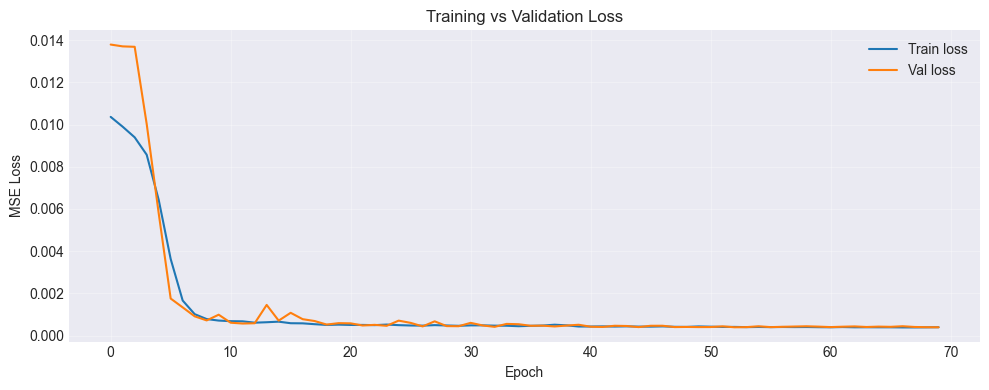

In [502]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses,   label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

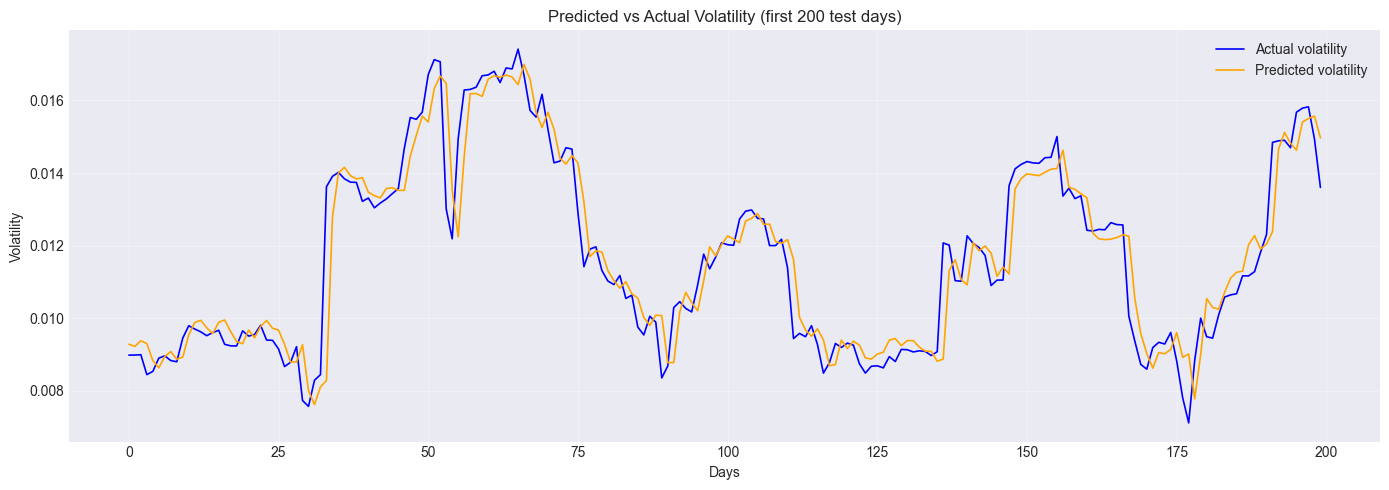

In [503]:
plt.figure(figsize=(14, 5))
plt.plot(true[:200],  label='Actual volatility',    color='blue',   linewidth=1.2)
plt.plot(preds[:200], label='Predicted volatility', color='orange', linewidth=1.2)
plt.title('Predicted vs Actual Volatility (first 200 test days)')
plt.xlabel('Days')
plt.ylabel('Volatility')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [504]:
# compare your model vs pure persistence
persistence_preds = true[:-1]   # today's vol as prediction for tomorrow
persistence_true  = true[1:]

persistence_rmse     = root_mean_squared_error(persistence_true, persistence_preds)
persistence_relative = persistence_rmse / persistence_true.mean()

print(f"Model         : {rmse/true.mean():.2%}")
print(f"Persistence   : {persistence_relative:.2%}")
print(f"Improvement   : {persistence_relative - rmse/true.mean():.2%}")

Model         : 9.60%
Persistence   : 9.67%
Improvement   : 0.07%


In [505]:
actual_change = true[1:] - true[:-1]
predicted_change = preds[1:] - true[:-1]

# 2. Check where the signs match (both up or both down)
correct_direction = np.sign(actual_change) == np.sign(predicted_change)

# 3. Calculate hit ratio
hit_ratio = np.mean(correct_direction)

print(f"Directional Hit Ratio: {hit_ratio:.2%}")

Directional Hit Ratio: 53.42%


In [ ]:
# torch.save(model.state_dict(), '../models/model_weights5.pth')

# ──────── Fine-Tuning ──────────

# the best parameters are:

window size (W) = 90

HIDDEN_SIZE = 128

NUM_LAYERS = 1

DROPOUT = 0.29255451180333386

LEARNING_RATE = 0.0011482784997348093

BATCH_SIZE = 64

PATIENCE = 17

quantile = 0.63